# Context and stopping

`generate_content` on `gemini-3.5-flash-lite`. History uses the same `turn()` as `cli/chat.py`: role `user` or `model`, one text part.


## Setup

In [3]:
import math
import sys
from collections import Counter
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "cli").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from google.genai.errors import ClientError

from cli import config
from cli.llm import complete, response_text
from cli.chat import turn

LIST_PROMPT = (
    "Write a numbered list of five fruits, one per line, in this shape:\n"
    "1. apple"
)


## Stop sequence

Ask for a numbered list. Stop at `3.`. The stop string is not part of the text you get back, and the list ends before item 3.


In [5]:
stopped = complete(LIST_PROMPT, stop=["3."], temperature=0, max_tokens=200)
stopped_text = response_text(stopped)
print(stopped_text)
print("---")
print("stop string present:", "3." in stopped_text)
print("finish_reason:", stopped.candidates[0].finish_reason)


1. apple
2. banana

---
stop string present: False
finish_reason: FinishReason.STOP


## Why it stopped

Three requests: the model finishes on its own, a stop sequence fires, `max_tokens` cuts it. Print `finish_reason` for each.


In [7]:
natural = complete("What is 2+2? Reply with one word.", temperature=0, max_tokens=32)
capped = complete(
    "Explain photosynthesis in several paragraphs, with the chemistry.",
    temperature=0,
    max_tokens=5,
)

cases = (
    ("natural end", natural),
    ("stop sequence", stopped),
    ("max_tokens", capped),
)
for label, response in cases:
    reason = response.candidates[0].finish_reason
    print(f"{label:<16} {reason}")
    print(repr(response_text(response)[:180]))
    print()


natural end      FinishReason.STOP
'Four'

stop sequence    FinishReason.STOP
'1. apple\n2. banana\n'

max_tokens       FinishReason.MAX_TOKENS
'Photos'



## `max_tokens=5` is a guillotine

The cap ends generation. It does not negotiate a shorter answer. The text stops wherever token 5 falls, including mid-word.


In [9]:
print(repr(response_text(capped)))
usage = capped.usage_metadata
print("finish_reason:        ", capped.candidates[0].finish_reason)
print("candidates_token_count:", usage.candidates_token_count)
print("thoughts_token_count:  ", usage.thoughts_token_count)


'Photos'
finish_reason:         FinishReason.MAX_TOKENS
candidates_token_count: 1
thoughts_token_count:   None


## Output tokens 0

`max_output_tokens` counts thinking and the visible answer together. A hard question with a small cap and `thinking_level=high` is the case where the visible count is 0 and the thought count is not. The bill uses the thought count. See `notes/05-token-counting-and-cost.md`.


In [11]:
spent = complete(
    "Prove that there are infinitely many primes.",
    max_tokens=16,
    thinking_level="high",
    temperature=0,
)
spent_usage = spent.usage_metadata
print("text:", repr(response_text(spent)))
print("finish_reason:        ", spent.candidates[0].finish_reason)
print("candidates_token_count:", spent_usage.candidates_token_count)
print("thoughts_token_count:  ", spent_usage.thoughts_token_count)


text: ''
finish_reason:         FinishReason.MAX_TOKENS
candidates_token_count: None
thoughts_token_count:   12


## Context growth

Ten turns, through `chat.py`'s rule: append the user turn, call, append the model turn. Record input tokens each turn. The model is stateless, so turn 10 resends turns 1–9.


turn  1  input tokens 13
turn  2  input tokens 28
turn  3  input tokens 43
turn  4  input tokens 58
turn  5  input tokens 73
turn  6  input tokens 88
turn  7  input tokens 103
turn  8  input tokens 118
turn  9  input tokens 133
turn 10  input tokens 148


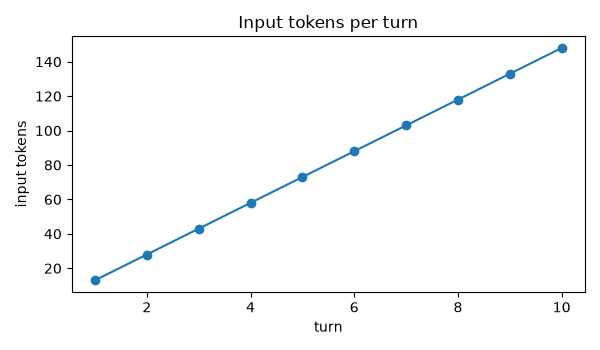

In [13]:
import matplotlib.pyplot as plt

history = []
input_tokens = []
for i in range(10):
    history.append(turn("user", f"Remember the number {i}. Reply with just {i}."))
    response = complete(history, max_tokens=8, temperature=0)
    count = response.usage_metadata.prompt_token_count or 0
    input_tokens.append(count)
    history.append(turn("model", response_text(response)))
    print(f"turn {i + 1:>2}  input tokens {count}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(range(1, 11), input_tokens, marker="o")
ax.set_xlabel("turn")
ax.set_ylabel("input tokens")
ax.set_title("Input tokens per turn")
fig.tight_layout()
fig.savefig(ROOT / "experiments" / "03-context-growth.png", dpi=120)
fig


## The hard wall

The documented input limit for this model is 1,048,576 tokens. This sends more than that on purpose. The expected result is HTTP 400, not a trimmed prompt.


In [ ]:
# "hello " is one token often enough that 1.2 million copies clears the window.
blob = "hello " * 1_200_000
print("characters:", len(blob))
try:
    complete(blob, max_tokens=1, temperature=0)
    print("accepted — the wall is higher than this string")
except ClientError as exc:
    print(f"{exc.code} {exc.status}")
    print(exc.message[:600])
